<a href="https://colab.research.google.com/github/felixgao1226/CSC311/blob/main/CSC311_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
responses = 275

url = "https://raw.githubusercontent.com/felixgao1226/CSC311/refs/heads/main/training_data_clean.csv"

data = pd.read_csv(url)
df = data.rename(columns={'In your own words, what kinds of tasks would you use this model for?': 'use_case',
                            'How likely are you to use this model for academic tasks?': 'rate_academic_usage',
                            'Which types of tasks do you feel this model handles best? (Select all that apply.)': 'best_tasks',
                            'Based on your experience, how often has this model given you a response that felt suboptimal?': 'rate_poor_response',
                            'For which types of tasks do you feel this model tends to give suboptimal responses? (Select all that apply.)': 'weak_tasks',
                            'Think of one task where this model gave you a suboptimal response. What did the response look like, and why did you find it suboptimal?': 'suboptimal_response',
                            'How often do you expect this model to provide responses with references or supporting evidence?': 'rate_reference_usage',
                            'How often do you verify this model\'s responses?': 'rate_response_verification',
                            'When you verify a response from this model, how do you usually go about it?': 'verification_method',
                            })

In [ ]:
#df["label"].value_counts()
#df['rate_academic_usage'].value_counts()
#df['rate_poor_response'].value_counts()
#df['rate_reference_usage'].value_counts()
#df["rate_response_verification"].value_counts()
#print(df)


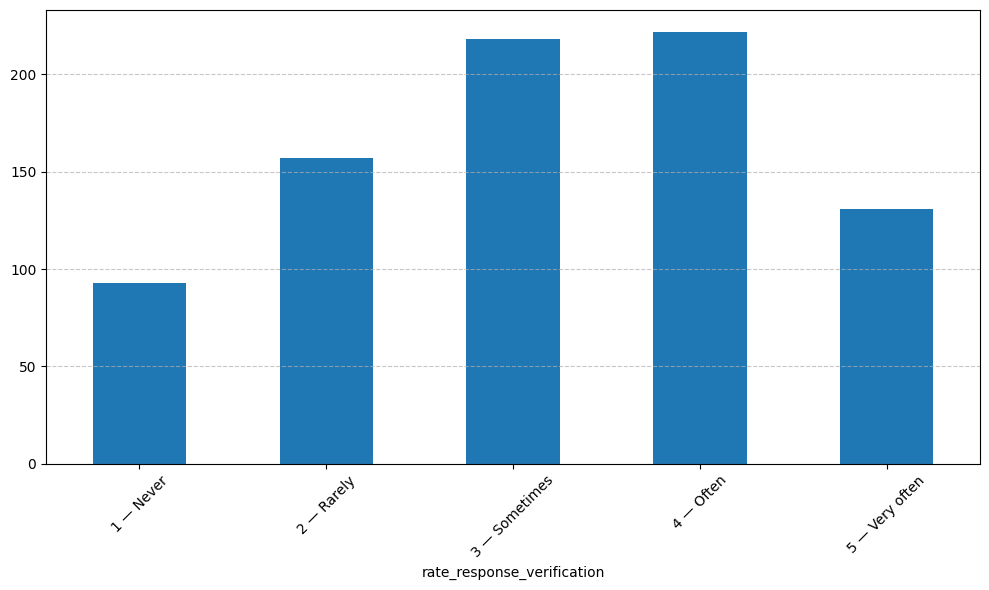

In [ ]:
# Get the value counts of the 'rate_academic_usage' column
academic_usage_counts = df['rate_response_verification'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
academic_usage_counts.plot(kind='bar')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df['use_case'] = df['use_case'].str.lower()
df['suboptimal_response'] = df['suboptimal_response'].str.lower()
df['verification_method'] = df['verification_method'].str.lower()

In [ ]:
def make_bool(data):
    """
    Produce a boolean feature matrix representation of the data for
    multiple-select questions.

    Parameters:
        `data`: a list of multiple-select questions with each choice seperated
                by comma

    Returns:
        `X`: A data matrix of boolean features.
    """
    Clean = data.str.replace(', ', '')
    return Clean.str.get_dummies(',')

In [ ]:
def make_bool_choice(data, choices):
    """
    """
    choice_repr = []
    for choice in choices:
        choice_repr.append(data.str.contains(choice, na=False, regex=False))
    bool_matrix = pd.concat(choice_repr, axis=1)
    bool_matrix.columns = choices
    return bool_matrix.astype(int)

In [ ]:
import re

split_regex = r'\b[A-Za-z0-9\']+\b|\[another model\]|\[this model\]'

def find_vocab(data):
    """
    """
    vocab = []

    for sample in data:
        sample = str(sample)
        words = re.findall(split_regex, sample)
        for word in words:
            if word not in vocab:
                vocab.append(word)

    return vocab

In [ ]:
# def make_bow(data, vocab):
#     """
#     Produce the bag-of-word representation of the data, along with a vector
#     of labels. You *may* use loops to iterate over `data`.

#     Parameters:
#         `data`: a list of `(review, label)` pairs, like those produced from
#                 `list(csv.reader(open("trainvalid.csv")))`
#         `vocab`: a list consisting of all unique words in the vocabulary

#     Returns:
#         `X`: A data matrix of bag-of-word features. This data matrix should be
#              a numpy array with shape [len(data), len(vocab)].
#              Moreover, `X[i,j] == 1` if the review in `data[i]` contains the
#              word `vocab[j]`, and `X[i,j] == 0` otherwise.
#         `t`: A numpy array of shape [len(data)], with `t[i] == 1` if
#              `data[i]` is a positive review, and `t[i] == 0` otherwise.
#     """
#     X = np.zeros([len(data), len(vocab)], dtype = int)

#     for i in range(len(data)):
#         s = str(data.iloc[i])
#         for w in re.findall(split_regex, s):
#             for j in range(len(vocab)):
#                 if w == vocab[j]:
#                     X[i, j] = 1

#     return X

In [ ]:
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer

# example
# split_regex = r"[A-Za-z]+"

def make_bow(data, vocab):
    """
    data: pandas Series or list of strings (reviews)
    vocab: list of words (fixed vocabulary, column order)

    returns:
        X: numpy array [len(data), len(vocab)],
           X[i,j] = 1 if vocab[j] appears in data[i], else 0
    """
    # if it's a pandas Series, convert to list of strings
    texts = [str(x) for x in data]

    vectorizer = CountVectorizer(
        vocabulary=vocab,
        binary=True,
        tokenizer=lambda s: re.findall(split_regex, s),
        token_pattern=None,  # required when using custom tokenizer
        lowercase=False
    )

    X_sparse = vectorizer.transform(texts)
    X = X_sparse.toarray().astype(int)
    return X



In [ ]:
def vocab_count(bow):
    """
    """
    vocab_count_mapping = list(zip(UCVocab, np.sum(bow, axis=0)))
    return sorted(vocab_count_mapping, key=lambda e: e[1], reverse=True)

Text(0, 0.5, 'Number of occurrences')

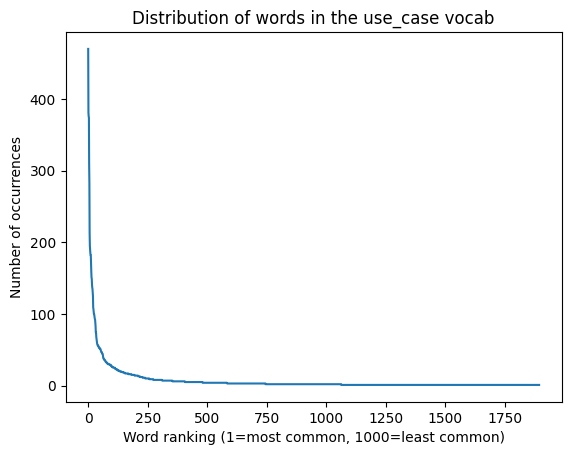

In [ ]:
#test

UCVocab = find_vocab(df['use_case'])
SRVocab = find_vocab(df['suboptimal_response'])
VMVocab = find_vocab(df['verification_method'])
#for word, n in vocab_count(make_bow(df['use_case'], UCVocab)):
#  print(word, n)
plt.plot([cnt for word, cnt in vocab_count(make_bow(df['use_case'], UCVocab))])
plt.title("Distribution of words in the use_case vocab")
plt.xlabel("Word ranking (1=most common, 1000=least common)")
plt.ylabel("Number of occurrences")

In [ ]:
def clean_vocab(vocab_count_mapping: list, min: int, max: int, stop_words: list):
    """
    Removes all words that are below the threshold or in the stop_words.
    Return a new list of words.
    """
    new_vocab = []
    for word, n in vocab_count_mapping:
        if n >= min and word not in stop_words and n <= max:
            new_vocab.append(word)
    return new_vocab

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_layers, output_size, learning_rate=0.01):
        """
        input_size: number of features in training data
        hidden_layers: list of integers, each is number of neurons in that hidden layer
        output_size: number of classes
        learning_rate: step size for gradient descent
        """
        self.learning_rate = learning_rate
        layer_sizes = [input_size] + hidden_layers + [output_size]

        self.weights = []
        self.biases = []
        for i in range(len(layer_sizes)-1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) / np.sqrt(layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def activation(self, x):
        return np.maximum(0, x)

    def activation_derivative(self, x):
        return (x > 0).astype(float)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        activations = [X]
        pre_activations = []

        for i in range(len(self.weights)-1):
            z = activations[-1] @ self.weights[i] + self.biases[i]
            pre_activations.append(z)
            a = self.activation(z)
            activations.append(a)
        z = activations[-1] @ self.weights[-1] + self.biases[-1]
        pre_activations.append(z)
        a = self.softmax(z)
        activations.append(a)

        return activations, pre_activations

    def backward(self, X, y, activations, pre_activations):
        m = X.shape[0]
        grads_w = []
        grads_b = []
        y_onehot = np.zeros_like(activations[-1])
        y_onehot[np.arange(m), y] = 1
        delta = (activations[-1] - y_onehot) / m
        for i in reversed(range(len(self.weights))):
            a_prev = activations[i]
            dw = a_prev.T @ delta
            db = np.sum(delta, axis=0, keepdims=True)

            grads_w.insert(0, dw)
            grads_b.insert(0, db)

            if i > 0:
                delta = (delta @ self.weights[i].T) * self.activation_derivative(pre_activations[i-1])

        return grads_w, grads_b

    def update(self, grads_w, grads_b):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * grads_w[i]
            self.biases[i] -= self.learning_rate * grads_b[i]

    def train(self, X_train, y_train, X_val, y_val, epochs=1000):
        for epoch in range(epochs):
            activations, pre_activations = self.forward(X_train)
            grads_w, grads_b = self.backward(X_train, y_train, activations, pre_activations)
            self.update(grads_w, grads_b)
            loss = -np.mean(np.log(activations[-1][np.arange(len(y_train)), y_train]))
            train_preds = self.predict(X_train)
            train_acc = np.mean(train_preds == y_train)
            val_preds = self.predict(X_val)
            val_acc = np.mean(val_preds == y_val)
            if epoch % 100 == 0 or epoch == epochs-1:
                print(f"Epoch {epoch}, Loss: {loss:.4f}, "
                      f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")


    def predict(self, X):
        activations, _ = self.forward(X)
        return np.argmax(activations[-1], axis=1)

    def get_representation(self, X):
        activations, _ = self.forward(X)
        return activations[-2]   # last hidden layer BEFORE softmax



In [ ]:
students = df['student_id'].unique()
np.random.shuffle(students)
df = pd.concat([df[df['student_id'] == s] for s in students])
df = df.reset_index(drop=True)

train = df[:525]
valid = df[525:675]
test = df[675:]

In [ ]:
dirty_vocab = find_vocab(train['use_case'])
dirty_bow = make_bow(train['use_case'], UCVocab)
dirty_vocab_count = vocab_count(dirty_bow)
polished_vocab = clean_vocab(dirty_vocab_count, 10, 1000, [])

label_dict = {'ChatGPT': 0,
                'Claude': 1,
                'Gemini': 2}

train_X = make_bow(train['use_case'], polished_vocab)
train_t = train['label'].map(label_dict).to_numpy()
valid_X = make_bow(valid['use_case'], polished_vocab)
valid_t = valid['label'].map(label_dict).to_numpy()
test_X = make_bow(test['use_case'], polished_vocab)
test_t = test['label'].map(label_dict).to_numpy()

In [ ]:
input_size = train_X.shape[1]
hidden_layers = [100, 100]
output_size = 3
learning_rate = 0.02

nn = NeuralNetwork(input_size, hidden_layers, output_size, learning_rate)
nn.train(train_X, train_t, valid_X, valid_t, 5000)

Epoch 0, Loss: 1.1014, Train Acc: 0.3314, Val Acc: 0.2933
Epoch 100, Loss: 1.0703, Train Acc: 0.4648, Val Acc: 0.4200
Epoch 200, Loss: 1.0408, Train Acc: 0.5371, Val Acc: 0.4600
Epoch 300, Loss: 1.0047, Train Acc: 0.5752, Val Acc: 0.5000
Epoch 400, Loss: 0.9591, Train Acc: 0.6190, Val Acc: 0.5200
Epoch 500, Loss: 0.9040, Train Acc: 0.6571, Val Acc: 0.5067
Epoch 600, Loss: 0.8441, Train Acc: 0.6857, Val Acc: 0.5200
Epoch 700, Loss: 0.7847, Train Acc: 0.7067, Val Acc: 0.5000
Epoch 800, Loss: 0.7277, Train Acc: 0.7238, Val Acc: 0.4933
Epoch 900, Loss: 0.6730, Train Acc: 0.7410, Val Acc: 0.4933
Epoch 1000, Loss: 0.6203, Train Acc: 0.7619, Val Acc: 0.5000
Epoch 1100, Loss: 0.5702, Train Acc: 0.7829, Val Acc: 0.4933
Epoch 1200, Loss: 0.5224, Train Acc: 0.8038, Val Acc: 0.5200
Epoch 1300, Loss: 0.4772, Train Acc: 0.8248, Val Acc: 0.5333
Epoch 1400, Loss: 0.4348, Train Acc: 0.8438, Val Acc: 0.5467
Epoch 1500, Loss: 0.3958, Train Acc: 0.8552, Val Acc: 0.5400
Epoch 1600, Loss: 0.3597, Train Acc:

KeyboardInterrupt: 

In [ ]:
df.columns

In [ ]:
nns = []
train_repr_list = []
valid_repr_list = []
test_repr_list  = []
for feature in df.columns:
    print("Training nn on feature " + feature)
    train_X = make_bow(train[feature], polished_vocab)
    train_t = train['label'].map(label_dict).to_numpy()
    valid_X = make_bow(valid[feature], polished_vocab)
    valid_t = valid['label'].map(label_dict).to_numpy()
    test_X = make_bow(test[feature], polished_vocab)
    test_t = test['label'].map(label_dict).to_numpy()

    input_size = train_X.shape[1]
    hidden_layers = [100, 100]
    output_size = 3
    learning_rate = 0.02

    nn = NeuralNetwork(input_size, hidden_layers, output_size, learning_rate)
    nn.train(train_X, train_t, valid_X, valid_t, 3000)
    nns.append(nn)

    train_repr = nn.get_representation(train_X)
    valid_repr = nn.get_representation(valid_X)
    test_repr  = nn.get_representation(test_X)

    train_repr_list.append(train_repr)
    valid_repr_list.append(valid_repr)
    test_repr_list.append(test_repr)

X_final_train = np.concatenate(train_repr_list, axis=1)
X_final_valid = np.concatenate(valid_repr_list, axis=1)
X_final_test  = np.concatenate(test_repr_list,  axis=1)

print("Final train shape:", X_final_train.shape)
print("Final valid shape:", X_final_valid.shape)
print("Final test shape:",  X_final_test.shape)

y_train = train_t
y_valid = valid_t
y_test  = test_t

input_size_final = X_final_train.shape[1]
hidden_layers_final = [100, 100]
output_size = 3
learning_rate = 0.02

final_nn = NeuralNetwork(input_size_final, hidden_layers_final, output_size, learning_rate)
final_nn.train(X_final_train, y_train, X_final_valid, y_valid, epochs=5000)

test_preds = final_nn.predict(X_final_test)
test_acc = np.mean(test_preds == y_test)
print("Final NN test accuracy:", test_acc)

Training nn on feature student_id
Epoch 0, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 100, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 200, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 300, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 400, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 500, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 600, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 700, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 800, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 900, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 1000, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 1100, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 1200, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 1300, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 1400, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Epoch 1500, Loss: 1.0986, Train Acc: 0.3333, Val Acc: 0.3333
Ep

In [ ]:
print(df.columns)

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

columns = [df.columns[2], df.columns[3], df.columns[4], df.columns[5], df.columns[7], df.columns[8]]
columns = df.columns[1:10]
train_repr_list = []
valid_repr_list = []
test_repr_list  = []
for feature in columns:
    if feature == 'use_case' or feature == 'suboptimal_response' or feature == 'verification_method':
        dirty_vocab = find_vocab(train[feature])
        dirty_bow = make_bow(train[feature], dirty_vocab)
        dirty_vocab_count = vocab_count(dirty_bow)
        polished_vocab = clean_vocab(dirty_vocab_count, 15, int(train_X.shape[0]*0.85), ENGLISH_STOP_WORDS)

        train_repr_list.append(make_bow(train[feature], polished_vocab))
        valid_repr_list.append(make_bow(valid[feature], polished_vocab))
        test_repr_list.append(make_bow(test[feature], polished_vocab))

        continue


    choices = make_bool(train[feature]).columns

    train_repr_list.append(make_bool_choice(train[feature], choices))
    valid_repr_list.append(make_bool_choice(valid[feature], choices))
    test_repr_list.append(make_bool_choice(test[feature], choices))

final_train = np.concatenate(train_repr_list, axis=1)
final_valid = np.concatenate(valid_repr_list, axis=1)
final_test  = np.concatenate(test_repr_list, axis=1)

print(final_train.shape)

In [ ]:
input_size = final_train.shape[1]
hidden_layers = [200, 200]
output_size = 3
learning_rate = 0.015

print(input_size)

nn = NeuralNetwork(input_size, hidden_layers, output_size, learning_rate)
nn.train(final_train, train_t, final_valid, valid_t, epochs=1500)

test_preds = nn.predict(final_test)
test_acc = np.mean(test_preds == test_t)
print("Final NN test accuracy:", test_acc)

NameError: name 'final_train' is not defined

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(200,4), max_iter=2000)

mlp.fit(np.concatenate([final_train, final_valid], axis=0), np.concatenate([train_t, valid_t], axis=0))

print(np.mean(mlp.predict(final_test) == test_t))

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(np.concatenate([final_train, final_valid], axis=0), np.concatenate([train_t, valid_t], axis=0))

print(np.mean(model.predict(final_test) == test_t))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion='gini', max_depth=5)
clf.fit(np.concatenate([final_train, final_valid], axis=0), np.concatenate([train_t, valid_t], axis=0))

print(np.mean(clf.predict(final_test) == test_t))